<a href="https://colab.research.google.com/github/aryan-gupta123/NBA-Predictor-ML-Model/blob/main/Nba_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


Importing the core Python libraries for data analysis and modeling.

pandas → for data handling

matplotlib → for simple visualizations

scikit-learn → for building and testing a predictive model

In [26]:
from google.colab import files
uploaded = files.upload()


Saving games.csv to games (2).csv


Manually downloading kaggle data set through upload from computer

In [57]:
# Load dataset (replace with your dataset path if local)
df = pd.read_csv("games.csv")

# Preview the first few rows
df.head()


,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,...,AST_home,REB_home,TEAM_ID_away,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,HOME_TEAM_WINS
0,2022-12-22,22200477,Final,1610612740,1610612759,2022,1610612740,126.0,0.484,0.926,...,25.0,46.0,1610612759,117.0,0.478,0.815,0.321,23.0,44.0,1
1,2022-12-22,22200478,Final,1610612762,1610612764,2022,1610612762,120.0,0.488,0.952,...,16.0,40.0,1610612764,112.0,0.561,0.765,0.333,20.0,37.0,1
2,2022-12-21,22200466,Final,1610612739,1610612749,2022,1610612739,114.0,0.482,0.786,...,22.0,37.0,1610612749,106.0,0.470,0.682,0.433,20.0,46.0,1
3,2022-12-21,22200467,Final,1610612755,1610612765,2022,1610612755,113.0,0.441,0.909,...,27.0,49.0,1610612765,93.0,0.392,0.735,0.261,15.0,46.0,1
4,2022-12-21,22200468,Final,1610612737,1610612741,2022,1610612737,108.0,0.429,1.000,...,22.0,47.0,1610612741,110.0,0.500,0.773,0.292,20.0,47.0,0


We load our NBA games dataset into a pandas dataframe, then we use df.head() to see the first 5 rows of the table to ensure the data is loaded correctly

In [58]:
# Show all column names
df.columns


Index(['GAME_DATE_EST', 'GAME_ID', 'GAME_STATUS_TEXT', 'HOME_TEAM_ID',
       'VISITOR_TEAM_ID', 'SEASON', 'TEAM_ID_home', 'PTS_home', 'FG_PCT_home',
       'FT_PCT_home', 'FG3_PCT_home', 'AST_home', 'REB_home', 'TEAM_ID_away',
       'PTS_away', 'FG_PCT_away', 'FT_PCT_away', 'FG3_PCT_away', 'AST_away',
       'REB_away', 'HOME_TEAM_WINS'],
      dtype='object')

List out all column names so we know what data is being represented in our dataset, and so that we can refer back to the exact column names in our code

In [59]:
df.isnull().sum()

,0
GAME_DATE_EST,0
GAME_ID,0
GAME_STATUS_TEXT,0
HOME_TEAM_ID,0
VISITOR_TEAM_ID,0
SEASON,0
TEAM_ID_home,0
PTS_home,99
FG_PCT_home,99
FT_PCT_home,99


Check to see if there are any null values that will cause an error when we run a logistic regression

In [60]:
df=df.dropna()

Drop all null values to be able to run logistic regression on data

In [49]:
# Using points and field goal percentage to predict winner
features = ['FG_PCT_home','FG3_PCT_home', 'AST_home', 'REB_home',
            'FG_PCT_away','FG3_PCT_away', 'AST_away', 'REB_away']
X= df[features]
y=df['HOME_TEAM_WINS']




Using the column names we identified, we chose the variables we want to use to predict the winner of games

In [61]:
df[features].isnull().sum()

,0
FG_PCT_home,0
FG3_PCT_home,0
AST_home,0
REB_home,0
FG_PCT_away,0
FG3_PCT_away,0
AST_away,0
REB_away,0


Making sure we dropped all null values from data set, so logistic regression can be run

In [54]:
split = int(len(df) * 0.75)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]


We split data into 25% testing, on most recent data, and 75% training, on most historic data, so we can evaluate generalization.

In [55]:
model = LogisticRegression(max_iter=500)  # increase iterations for convergence
model.fit(X_train, y_train)


LogisticRegression(max_iter=500)

We train logistic regression. The max_iter=500 ensures the model converges since we have so many features

In [52]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8314818301638109

Confusion Matrix:
 [[1714  507]
 [ 388 2702]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.77      0.79      2221
           1       0.84      0.87      0.86      3090

    accuracy                           0.83      5311
   macro avg       0.83      0.82      0.83      5311
weighted avg       0.83      0.83      0.83      5311



We print accuracy, a confusion matrix, and precision/recall scores. This gives a much richer evaluation than just accuracy.

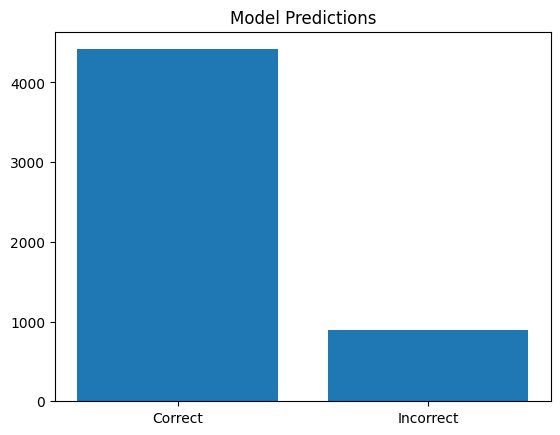

In [53]:
plt.bar(["Correct", "Incorrect"], [
    (y_pred == y_test).sum(),
    (y_pred != y_test).sum()
])
plt.title("Model Predictions")
plt.show()


This quick visualization shows how many predictions were correct vs incorrect.